In [378]:
library(readxl)
library(caret)
library(glmnet)
library(ggplotify)
library(randomForest)
library(ggfortify)

In [379]:
## Read previously processed data 
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')
response_name = 'cluster'

## Subset only the patients from the BECAME cohort
became_data = scaled_df[rownames(subset(meta,cohort=='BECAME' & group=='HFpEF')),]

miracle_data = scaled_df[rownames(subset(meta,cohort=='MIRACLE' & group=='HFpEF')),]
miracle_data$response_var = as.factor(meta[rownames(miracle_data),'cluster'])

In [380]:
## Subset the metadata 

## Log transform the intensities 
became_data$response_var = as.factor(as.numeric(meta[rownames(became_data),response_name]=='B1'))

## Create train/test indices 
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)

## Define training data 
became_data_train = became_data[index,]

In [381]:
cat('Overall representation of B1\n',
table(became_data$response_var),'\n\n')
cat('Train representation of B1\n',
table(became_data[index,]$response_var),'\n\n')
cat('Test representation of B1\n',
table(became_data[-index,]$response_var),'\n\n')

Overall representation of B1
 77 25 

Train representation of B1
 54 18 

Test representation of B1
 23 7 



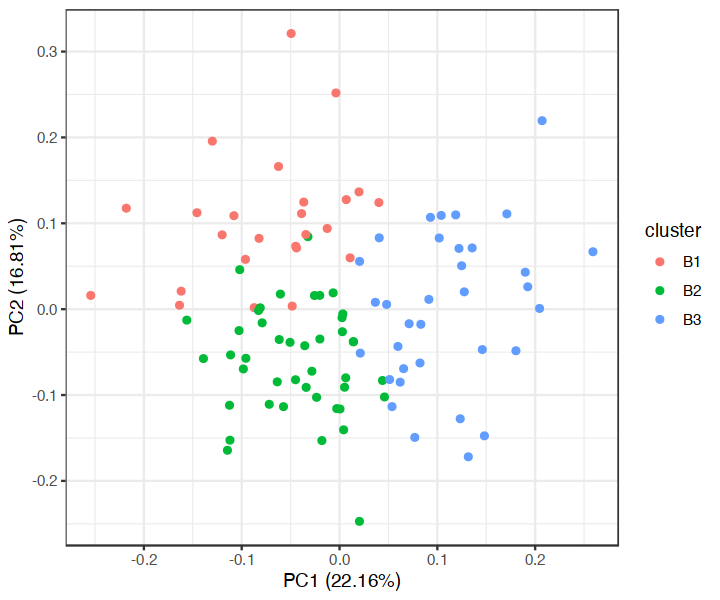

In [382]:
options(repr.plot.width = 6, repr.plot.height = 5)

autoplot(prcomp(became_data[,grepl('^X',colnames(became_data))]),data=meta[rownames(became_data),],col='cluster')+theme_bw()

In [383]:
options(warn = -1)
lipids = colnames(became_data)[grepl('^X',colnames(became_data))]

# Create a formula for the null model
null_model_formula <- as.formula(paste("response_var ~ 1"))
# Create a formula for lipids
lipids_formula <- as.formula(paste("response_var ~", paste(lipids, collapse = " + ")))

# Step 2: Forward-backward feature selection with BIC on lipids
null_model <- glm(null_model_formula, data = became_data_train, family = 'binomial')
lipids_model <- step(null_model, direction = "both", 
                     scope = list(lower = null_model_formula, 
                                  upper = lipids_formula), 
                     k = log(nrow(became_data_train)),trace = FALSE) 


predictions_became <- predict(lipids_model, newdata =  became_data[-index,], type = "response")


In [384]:
summary(lipids_model)


Call:
glm(formula = response_var ~ X132 + X16 + X104 + X73, family = "binomial", 
    data = became_data_train)

Deviance Residuals: 
       Min          1Q      Median          3Q         Max  
-8.303e-05  -2.100e-08  -2.100e-08  -1.100e-08   7.128e-05  

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -190.61   63518.25  -0.003    0.998
X132         -133.27   49032.42  -0.003    0.998
X16           -38.46   57748.00  -0.001    0.999
X104          -84.67   54289.98  -0.002    0.999
X73           -67.57   36205.05  -0.002    0.999

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 8.0976e+01  on 71  degrees of freedom
Residual deviance: 1.9602e-08  on 67  degrees of freedom
AIC: 10

Number of Fisher Scoring iterations: 25


In [385]:
confusionMatrix(became_data[-index,]$response_var,as.factor(round(predictions_became)))

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 20  3
         1  2  5
                                          
               Accuracy : 0.8333          
                 95% CI : (0.6528, 0.9436)
    No Information Rate : 0.7333          
    P-Value [Acc > NIR] : 0.1501          
                                          
                  Kappa : 0.5562          
                                          
 Mcnemar's Test P-Value : 1.0000          
                                          
            Sensitivity : 0.9091          
            Specificity : 0.6250          
         Pos Pred Value : 0.8696          
         Neg Pred Value : 0.7143          
             Prevalence : 0.7333          
         Detection Rate : 0.6667          
   Detection Prevalence : 0.7667          
      Balanced Accuracy : 0.7670          
                                          
       'Positive' Class : 0               
                                    

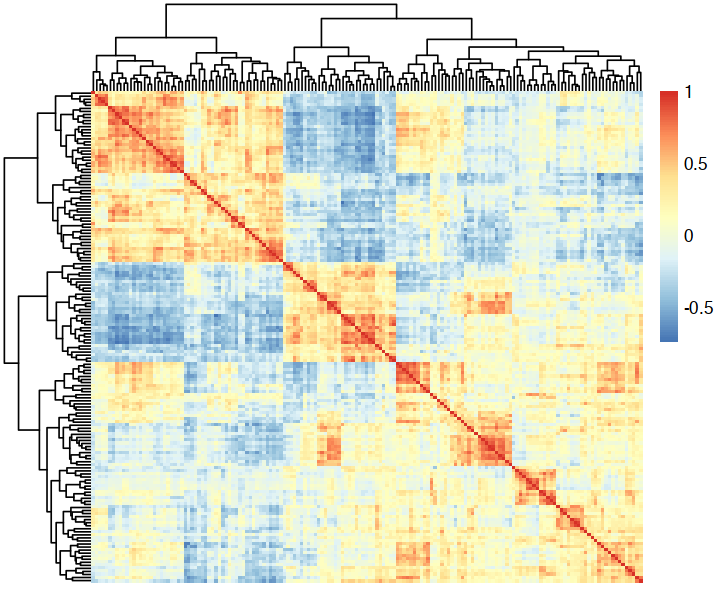

In [386]:
pheatmap::pheatmap(cor(became_data[,grepl('^X',colnames(became_data))]),fontsize_row=1e-5,fontsize_col=1e-5)

In [387]:
meta_miracle = subset(meta,cohort=='MIRACLE')

In [388]:
became_data$response_var = as.factor(meta[rownames(became_data),response_name])

In [389]:

## Log transform the intensities 
became_data$response_var = as.factor(meta[rownames(became_data),response_name])

## Create train/test indices 
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)

## Define training data 
became_data_train = became_data[index,]

x = became_data[index,grepl('^X',colnames(became_data))]
y = became_data[index,]$response_var
cv_model <- cv.glmnet(as.matrix(x), y, alpha = 1,family='multinomial', type.multinomial="grouped")

lambda_min <- cv_model$lambda.min
lambda_1se <- cv_model$lambda.1se

min_model <- glmnet(as.matrix(x), y, alpha = 1, lambda = lambda_min, family='multinomial', type.multinomial="grouped")
se_model <- glmnet(as.matrix(x), y, alpha = 1, lambda = lambda_1se, family='multinomial', type.multinomial="grouped")

#preds =  predict(min_model, s = lambda_min, newx = as.matrix(became_data[-index,grepl('^X',colnames(became_data))]),type='response')
#confusionMatrix(became_data[-index,]$response_var,as.factor(round(preds)))
preds =  predict(se_model, s = lambda_1se, newx = as.matrix(miracle_data[,grepl('^X',colnames(miracle_data))]),type='class')


meta_miracle_noctl = subset(meta_miracle,group!='CONTROL')
meta_miracle_noctl[, 'preds'] = as.character(preds)


In [394]:
preds_became =  predict(se_model, s = lambda_1se, newx = as.matrix(became_data[-index,grepl('^X',colnames(became_data))]),type='class')
confusionMatrix(as.factor(preds_became),as.factor(became_data[-index,'response_var']))

Confusion Matrix and Statistics

          Reference
Prediction B1 B2 B3
        B1  5  0  0
        B2  1 12  0
        B3  1  0 10

Overall Statistics
                                          
               Accuracy : 0.931           
                 95% CI : (0.7723, 0.9915)
    No Information Rate : 0.4138          
    P-Value [Acc > NIR] : 6.602e-09       
                                          
                  Kappa : 0.8926          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: B1 Class: B2 Class: B3
Sensitivity             0.7143    1.0000    1.0000
Specificity             1.0000    0.9412    0.9474
Pos Pred Value          1.0000    0.9231    0.9091
Neg Pred Value          0.9167    1.0000    1.0000
Prevalence              0.2414    0.4138    0.3448
Detection Rate          0.1724    0.4138    0.3448
Detection Prevalence    0.1724    0.4483    0.3793
Balanced Accuracy       0.857

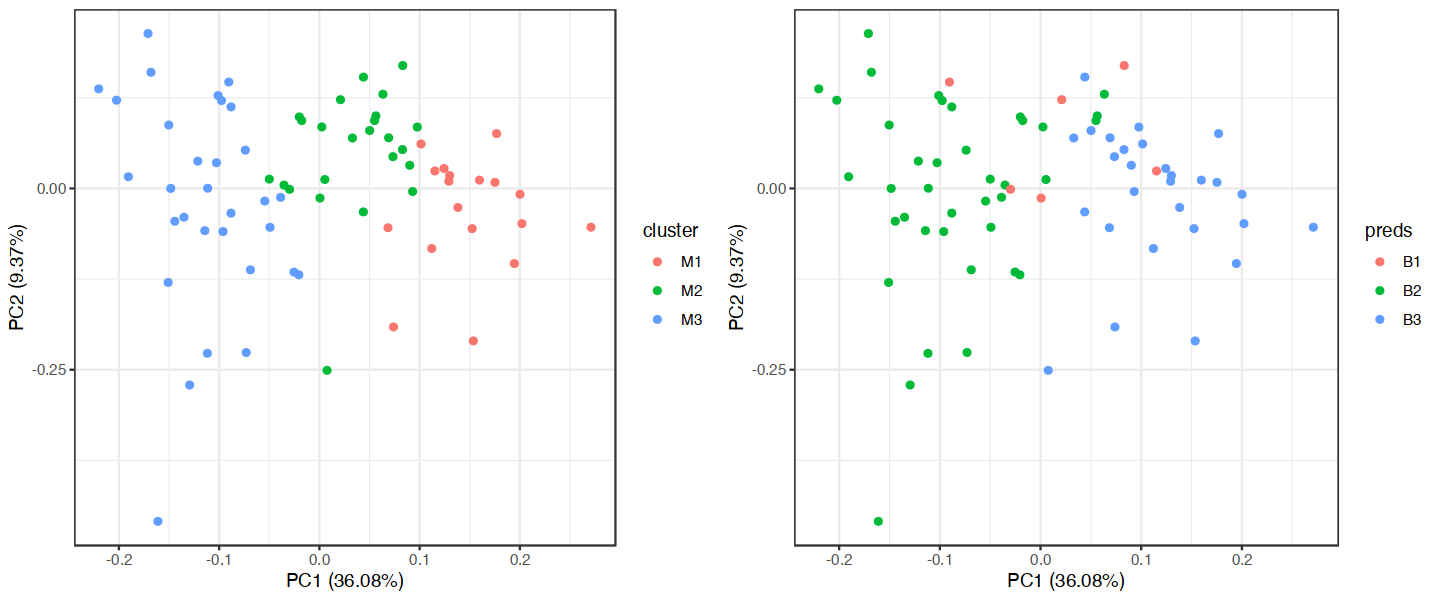

In [391]:
options(repr.plot.width = 12, repr.plot.height = 5)

p1 = autoplot(prcomp(miracle_data[,grepl('^X',colnames(miracle_data))]),data=meta_miracle_noctl,col='cluster')+theme_bw()
p2 = autoplot(prcomp(miracle_data[,grepl('^X',colnames(miracle_data))]),data=meta_miracle_noctl,col='preds')+theme_bw()

cowplot::plot_grid(p1,p2)

In [249]:
preds =  predict(se_model, s = lambda_1se, newx = as.matrix(became_data[-index,grepl('^X',colnames(became_data))]),type='response')
confusionMatrix(became_data[-index,]$response_var,as.factor(round(preds)))

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 23  0
         1  5  2
                                          
               Accuracy : 0.8333          
                 95% CI : (0.6528, 0.9436)
    No Information Rate : 0.9333          
    P-Value [Acc > NIR] : 0.98701         
                                          
                  Kappa : 0.3802          
                                          
 Mcnemar's Test P-Value : 0.07364         
                                          
            Sensitivity : 0.8214          
            Specificity : 1.0000          
         Pos Pred Value : 1.0000          
         Neg Pred Value : 0.2857          
             Prevalence : 0.9333          
         Detection Rate : 0.7667          
   Detection Prevalence : 0.7667          
      Balanced Accuracy : 0.9107          
                                          
       'Positive' Class : 0               
                                    

In [250]:
preds =  predict(min_model, s = lambda_min, newx = as.matrix(became_data[-index,grepl('^X',colnames(became_data))]),type='response')
confusionMatrix(became_data[-index,]$response_var,as.factor(round(preds)))

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 22  1
         1  4  3
                                          
               Accuracy : 0.8333          
                 95% CI : (0.6528, 0.9436)
    No Information Rate : 0.8667          
    P-Value [Acc > NIR] : 0.7970          
                                          
                  Kappa : 0.4526          
                                          
 Mcnemar's Test P-Value : 0.3711          
                                          
            Sensitivity : 0.8462          
            Specificity : 0.7500          
         Pos Pred Value : 0.9565          
         Neg Pred Value : 0.4286          
             Prevalence : 0.8667          
         Detection Rate : 0.7333          
   Detection Prevalence : 0.7667          
      Balanced Accuracy : 0.7981          
                                          
       'Positive' Class : 0               
                                    

In [251]:
lambda_min_predictors

[1] "(Intercept)" "X3"          "X6"          "X16"         "X49"        
 [6] "X51"         "X58"         "X61"         "X64"         "X73"        
[11] "X83"         "X84"         "X104"        "X124"        "X132"       
[16] "X143"        "X144"        "X154"

In [252]:
miracle_data = scaled_df[rownames(subset(meta,cohort=='MIRACLE' & group=='HFpEF')),]
miracle_data$response_var = as.factor(meta[rownames(miracle_data),'cluster'])

In [253]:
preds =  predict(min_model, s = lambda_min, newx = as.matrix(miracle_data[,grepl('^X',colnames(miracle_data))]),type='response')
table(miracle_data$response_var,as.factor(round(preds)))

    
      0  1
  M1 18  0
  M2 24  0
  M3 29  2

In [254]:
preds =  predict(se_model, s = lambda_1se, newx = as.matrix(miracle_data[,grepl('^X',colnames(miracle_data))]),type='response')
table(miracle_data$response_var,as.factor(round(preds)))

    
      0
  M1 18
  M2 24
  M3 31

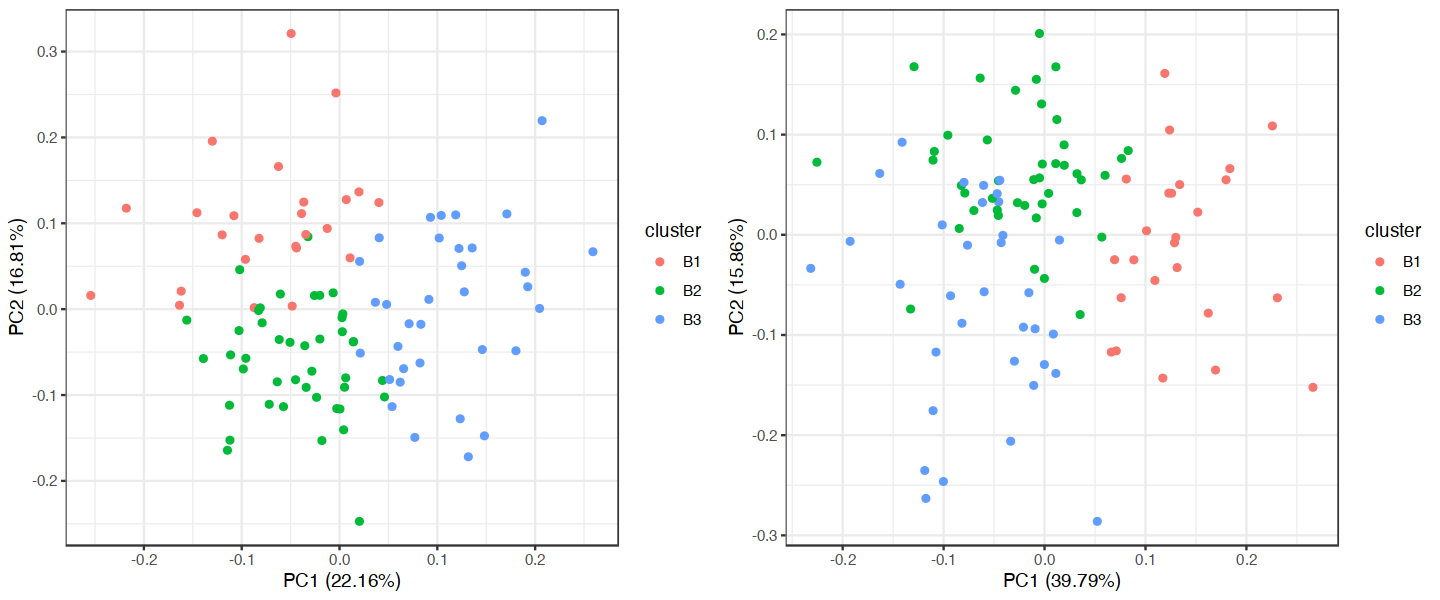

In [229]:
library(ggfortify)

options(repr.plot.width = 12, repr.plot.height = 5)

p1 = autoplot(prcomp(became_data[,grepl('^X',colnames(became_data))]),data=meta[rownames(became_data),],col='cluster')+theme_bw()
p2 = autoplot(prcomp(became_data[,lambda_min_predictors[-1]]),data=meta[rownames(became_data),],col='cluster')+theme_bw()

cowplot::plot_grid(p1,p2,ncol=2)